# 05 · JEPA — self-supervised perception for the learned ensemble

**JEPA** (Joint-Embedding Predictive Architecture) is *not* a fusion mode. It is a
small self-supervised scene model whose signals feed the `rl_gated` policy so the
trust decision can react to how reliable the visual world currently looks. This
notebook builds and dissects the built-in **JEPA-lite** end to end on the
hexacopter slice — no ground truth involved.

### The idea

> Embed each camera frame, then **predict the next frame's embedding from the
> current one plus how the IMU says the camera moved**. When the real next frame
> doesn't match the prediction, that **surprise** means the visual stream is
> momentarily unreliable.

Three parts (`src/nav_benchmark/jepa/model.py`):

- an **online patch encoder** → a frame embedding,
- an **EMA target encoder** (slow copy) → stable prediction targets,
- an **ego-motion-conditioned predictor**: `(embedding_t, ego_motion) → embedding_{t+1}`.

It is trained by minimizing cosine distance between prediction and target, plus a
variance hinge that stops the embeddings from collapsing (VICReg-style). At
inference it emits **surprise** (prediction error) and **embedding speed**, which
become 3 extra features in the RL observation (see notebooks 03 & 04).

> Where this fits: the `rl_gated` merger is **EKF + RL policy + JEPA**. Notebook
> 04 covers the EKF/RL merging mechanics; this one is the JEPA piece.

In [1]:
# --- Notebook bootstrap: put the src/ package on the path, pick the dataset ---
import sys, time, warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 92

DATA = ROOT / "data"
CANDIDATES = ["indoor_flying1_5s20s_img.h5", "indoor_flying1_5s20s.h5"]
SEQ_PATH = next((DATA / c for c in CANDIDATES if (DATA / c).exists()), None)
assert SEQ_PATH is not None, (
    "No hexacopter slice found under data/. Regenerate one (needs the MVSEC bags) with:\n"
    "  uv run python scripts/convert_mvsec_bag_to_h5.py \\\n"
    "    --data-bag data/indoor_flying1_data.bag --gt-bag data/indoor_flying1_gt.bag \\\n"
    "    --output data/indoor_flying1_5s20s_img.h5 --start-sec 5 --duration-sec 15 --include-images"
)
print("Repo root :", ROOT)
print("Sequence  :", SEQ_PATH.name)

Repo root : /home/jovyan/event-based-vio
Sequence  : indoor_flying1_5s20s_img.h5


In [2]:
from nav_benchmark.datasets.mvsec import load_mvsec_sequence
from nav_benchmark.events.representations import ensure_event_frames

# JEPA works on frame streams only (RGB APS frames and/or accumulated event
# frames) — it needs neither the odometry backends nor ground truth.
seq = load_mvsec_sequence(SEQ_PATH)
ensure_event_frames(seq, window_sec=0.05)
gravity = np.array([0.0, 0.0, 9.81])
has_rgb = seq.images is not None and len(seq.images) > 1
print(f"RGB frames  : {0 if not has_rgb else len(seq.images)}")
print(f"event frames: {len(seq.event_frames)}")

RGB frames  : 470
event frames: 300


## 1 · Frame preprocessing → patches

Any frame (RGB or event, any size) is normalized to a **32×32 grayscale** image
and split into a **4×4 grid of 8×8 patches**, each patch standardized — a
`(16 patches, 64 dims)` tensor per frame. `stack_frame_patches` does a whole
stream at once.

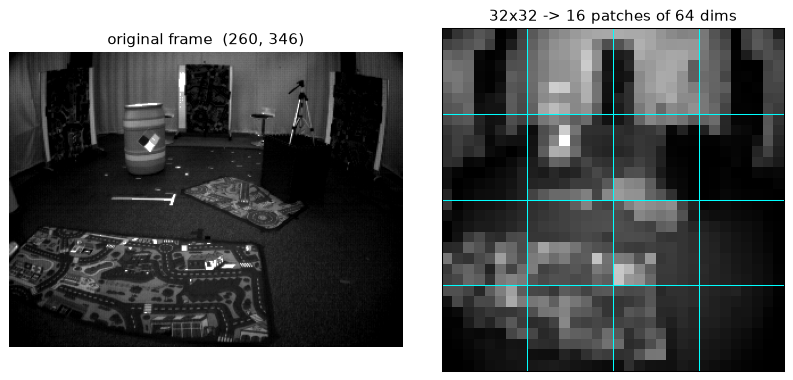

event patch tensor: (300, 16, 64) | one frame -> (16, 64)


In [3]:
import cv2
from nav_benchmark.jepa.frames import (
    frame_patches, stack_frame_patches, to_gray_float, INPUT_SIZE, NUM_PATCHES, PATCH_DIM,
)

frame0 = seq.images[len(seq.images) // 2] if has_rgb else seq.event_frames[len(seq.event_frames) // 2]
gray32 = cv2.resize(to_gray_float(frame0), (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_AREA)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(9, 4.2))
a0.imshow(frame0, cmap="gray"); a0.set_title(f"original frame  {frame0.shape}"); a0.axis("off")
a1.imshow(gray32, cmap="gray"); a1.set_title(f"{INPUT_SIZE}x{INPUT_SIZE} -> {NUM_PATCHES} patches of {PATCH_DIM} dims")
for g in range(1, INPUT_SIZE // 8):
    a1.axhline(8 * g - 0.5, color="cyan", lw=0.8); a1.axvline(8 * g - 0.5, color="cyan", lw=0.8)
a1.set_xticks([]); a1.set_yticks([])
plt.tight_layout(); plt.show()

rgb_patches = stack_frame_patches(seq.images) if has_rgb else None
evt_patches = stack_frame_patches(seq.event_frames)
print("event patch tensor:", evt_patches.shape, "| one frame ->", frame_patches(frame0).shape)

## 2 · Ego-motion conditioning (ground-truth-free)

The predictor is told *how the camera moved* between consecutive frames: a 7-D
vector = **body-frame translation (3) + relative rotation vector (3) + Δt (1)**.
Crucially this comes from **IMU-only propagation**, not ground truth, so the exact
same signal is available at training and inference time.

ego feature dim = 7; event-stream ego shape = (299, 7)


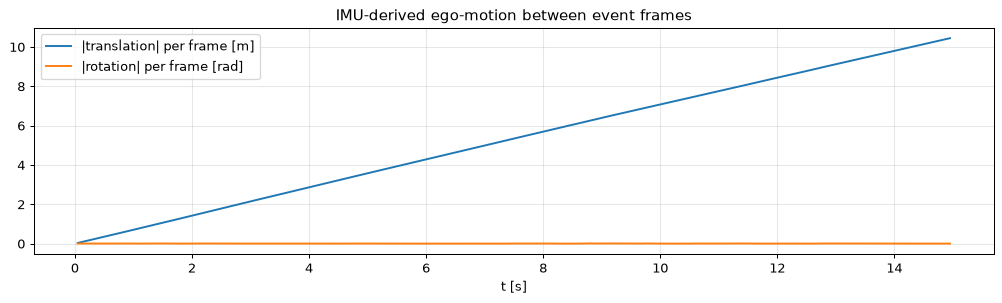

In [4]:
from nav_benchmark.jepa.frames import ego_motion_features, EGO_DIM
from nav_benchmark.jepa.signals import imu_reference_trajectory

reference = imu_reference_trajectory(seq, gravity)   # (times, positions, orientations) from IMU-only
ego_evt = ego_motion_features(reference[0], reference[1], reference[2], seq.event_frame_timestamps)
ego_rgb = ego_motion_features(reference[0], reference[1], reference[2], seq.image_timestamps) if has_rgb else None
print(f"ego feature dim = {EGO_DIM}; event-stream ego shape = {ego_evt.shape}")

te = seq.event_frame_timestamps[1:] - seq.event_frame_timestamps[0]
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(te, np.linalg.norm(ego_evt[:, 0:3], axis=1), label="|translation| per frame [m]")
ax.plot(te, np.linalg.norm(ego_evt[:, 3:6], axis=1), label="|rotation| per frame [rad]")
ax.set_title("IMU-derived ego-motion between event frames"); ax.set_xlabel("t [s]"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3 · Self-supervised training

Build consecutive-frame `(now, next, ego)` pairs (never crossing stream
boundaries) and train JEPA-lite. The loss is cosine distance between the
predicted and target next-embedding + a variance hinge. No labels, no GT.

training pairs: 768  (RGB + event frames combined)


trained 300 steps in 2.0 s  (loss 1.301 -> 0.008)


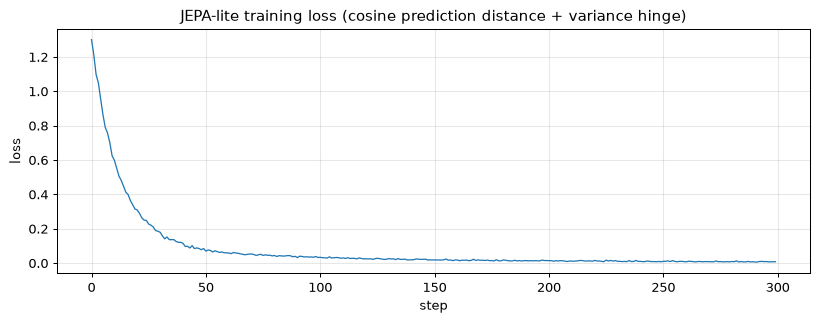

In [5]:
from nav_benchmark.jepa.model import JepaConfig, JepaModel, build_pair_dataset, train_jepa

segments = [(evt_patches, ego_evt)]
if has_rgb:
    segments.append((rgb_patches, ego_rgb))
now, nxt, ego = build_pair_dataset(segments)     # pairs never cross a stream boundary
print(f"training pairs: {len(now)}  (RGB + event frames combined)")

config = JepaConfig(embed_dim=32, hidden_dim=64, steps=300, batch_size=64, seed=0)
model = JepaModel(config)
t0 = time.perf_counter()
history = train_jepa(model, now, nxt, ego, device="cpu")
print(f"trained {len(history)} steps in {time.perf_counter()-t0:.1f} s  (loss {history[0]:.3f} -> {np.mean(history[-30:]):.3f})")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(history, lw=1.0)
ax.set_title("JEPA-lite training loss (cosine prediction distance + variance hinge)")
ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4 · Inference signals: surprise & embedding speed

- **Surprise** = cosine distance between the *predicted* next embedding and the
  *actual* one. High ⇒ the scene didn't evolve the way ego-motion predicted ⇒
  that visual stream is momentarily untrustworthy.
- **Embedding speed** = L2 step between consecutive embeddings (how fast the
  scene representation is changing).

Computed per stream against the same IMU ego-reference.

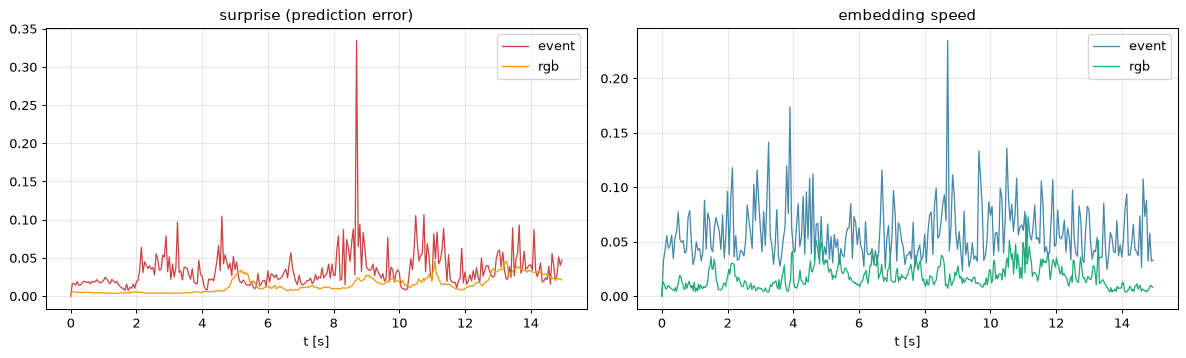

In [6]:
from nav_benchmark.jepa.model import surprise_scores, embedding_speeds

s_evt = surprise_scores(model, evt_patches, ego_evt)
v_evt = embedding_speeds(model, evt_patches)
te = seq.event_frame_timestamps - seq.event_frame_timestamps[0]
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4))
a0.plot(te, s_evt, color="#c44", lw=1.0, label="event")
a1.plot(te, v_evt, color="#48a", lw=1.0, label="event")
if has_rgb:
    s_rgb = surprise_scores(model, rgb_patches, ego_rgb); v_rgb = embedding_speeds(model, rgb_patches)
    tr = seq.image_timestamps - seq.image_timestamps[0]
    a0.plot(tr, s_rgb, color="#e91", lw=1.0, label="rgb")
    a1.plot(tr, v_rgb, color="#2a7", lw=1.0, label="rgb")
a0.set_title("surprise (prediction error)"); a0.set_xlabel("t [s]"); a0.legend(); a0.grid(alpha=0.3)
a1.set_title("embedding speed"); a1.set_xlabel("t [s]"); a1.legend(); a1.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Intuition — where surprise spikes

Surprise should rise when the camera moves in ways the smooth ego-motion model
can't predict (fast rotation, sharp scene change). Below we overlay event-frame
surprise with IMU angular speed, and show the frame pair with the largest
prediction error. *(This is a tiny model trained on one 15 s slice — illustrative,
not a benchmarked perception system.)*

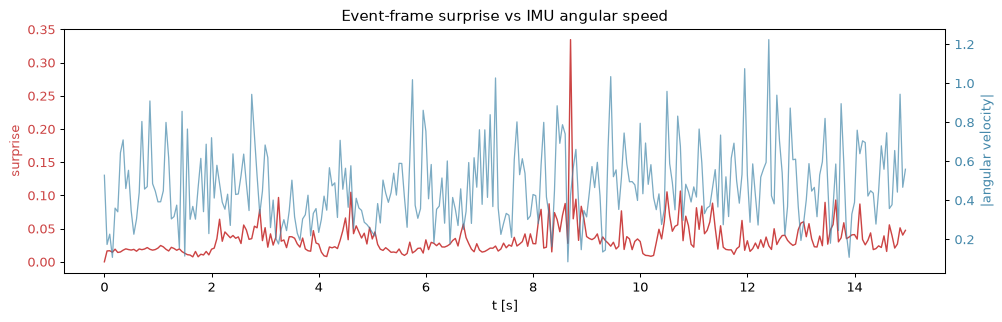

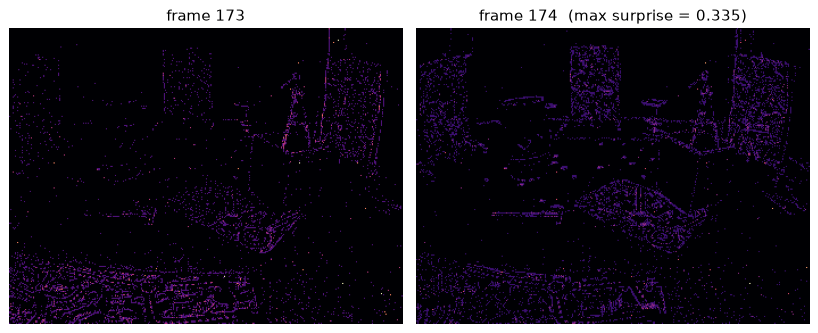

In [7]:
imu = seq.imu
gyro_mag = np.sqrt(imu["gx"]**2 + imu["gy"]**2 + imu["gz"]**2)
gyro_at_frames = np.interp(seq.event_frame_timestamps, imu["t"], gyro_mag)

fig, axL = plt.subplots(figsize=(11, 3.6))
axL.plot(te, s_evt, color="#c44", lw=1.1, label="event surprise")
axL.set_xlabel("t [s]"); axL.set_ylabel("surprise", color="#c44"); axL.tick_params(axis="y", labelcolor="#c44")
axR = axL.twinx()
axR.plot(te, gyro_at_frames, color="#48a", lw=1.0, alpha=0.7, label="|gyro| [rad/s]")
axR.set_ylabel("|angular velocity|", color="#48a"); axR.tick_params(axis="y", labelcolor="#48a")
axL.set_title("Event-frame surprise vs IMU angular speed")
plt.tight_layout(); plt.show()

k = int(np.argmax(s_evt))
fig, (b0, b1) = plt.subplots(1, 2, figsize=(9, 4.2))
b0.imshow(seq.event_frames[k - 1], cmap="magma"); b0.set_title(f"frame {k-1}"); b0.axis("off")
b1.imshow(seq.event_frames[k], cmap="magma"); b1.set_title(f"frame {k}  (max surprise = {s_evt[k]:.3f})"); b1.axis("off")
plt.tight_layout(); plt.show()

## 5 · How the signals reach the policy

`obs_series_for_sequence` merges the per-stream signals onto one causal time base
(`JepaObsSeries`). During an `rl_gated` run, `JepaObsSeries.at(t)` samples the
latest `(rgb_surprise, event_surprise, embedding_speed)` at each control-step
boundary; those 3 values are tanh-squashed and appended to the policy
observation (growing it from 44 to 47 features for this 5-backend layout).

In [8]:
from nav_benchmark.jepa.signals import obs_series_for_sequence

series = obs_series_for_sequence(model, seq, gravity=gravity)
print(f"JepaObsSeries: {len(series.times)} frame times, fields = "
      "[rgb_surprise, event_surprise, embedding_speed]")

# What the policy would read at three example control-step times.
demo_times = series.times[0] + np.array([2.0, 7.0, 12.0])
rows = {f"t={t - series.times[0]:.0f}s": np.round(series.at(t), 4) for t in demo_times}
display(pd.DataFrame(rows, index=["rgb_surprise", "event_surprise", "embedding_speed"]))
print("These 3 features append to the 44-D observation from notebook 04 -> 47-D with JEPA.")

JepaObsSeries: 770 frame times, fields = [rgb_surprise, event_surprise, embedding_speed]


,t=2s,t=7s,t=12s
rgb_surprise,0.0057,0.0108,0.0097
event_surprise,0.0189,0.0178,0.0317
embedding_speed,0.0557,0.0332,0.0372


These 3 features append to the 44-D observation from notebook 04 -> 47-D with JEPA.


## 6 · Using large pretrained JEPA models (I-JEPA / V-JEPA 2)

Real pretrained JEPA releases are hundreds of millions of parameters — run them
**offline on a GPU** and export per-frame embeddings to a simple file
(`/times (N,)` + `/embeddings (N, D)` in HDF5, or an NPZ with the same keys).
The adapter (`jepa/external.py`) then turns them into the same signal series;
without the paired predictor, surprise is approximated by the **cosine change
rate** of consecutive embeddings. Here we export our JEPA-lite embeddings as a
stand-in to exercise the exact plumbing.

In [9]:
import torch
from nav_benchmark.jepa.external import obs_series_from_files

emb = model.embed(torch.as_tensor(evt_patches, dtype=torch.float32)).detach().cpu().numpy()
ext_path = ROOT / "runs" / "nb05_event_embeddings.npz"
ext_path.parent.mkdir(parents=True, exist_ok=True)
np.savez(ext_path, times=np.asarray(seq.event_frame_timestamps), embeddings=emb)   # the file contract
print(f"wrote {emb.shape} embeddings -> {ext_path.name}")

ext_series = obs_series_from_files(event_path=ext_path)   # what --jepa-embeddings-events consumes
print(f"reloaded via external adapter: {len(ext_series.times)} times, "
      f"event_surprise max = {ext_series.event_surprise.max():.3f} (cosine-change approximation)")

wrote (300, 32) embeddings -> nb05_event_embeddings.npz
reloaded via external adapter: 300 times, event_surprise max = 0.370 (cosine-change approximation)


## Summary & commands

- JEPA-lite = **encoder + EMA target + ego-conditioned predictor**, trained
  self-supervised (no GT) on RGB and/or event frames.
- It outputs **surprise** (prediction error) and **embedding speed**, which are
  the perception features the `rl_gated` policy uses to anticipate visual
  failures — it never touches the trajectory itself.
- Two supply paths: the built-in `train-jepa` (local, shown here) or an adapter
  for embeddings precomputed by large pretrained I-JEPA / V-JEPA models.

```bash
# Local JEPA-lite (self-supervised, no GT):
uv run python -m nav_benchmark train-jepa --dataset mvsec \
    --input data/indoor_flying1_5s20s_img.h5 --output runs/jepa.pt --steps 500

# Feed it to the gating-policy trainer, then to a benchmark run:
uv run python -m nav_benchmark train-rl --dataset mvsec \
    --input data/indoor_flying1_5s20s_img.h5 --output-dir runs/rl --jepa runs/jepa.pt
uv run python -m nav_benchmark run --method ensemble --fusion rl_gated \
    --dataset mvsec --sequence indoor_flying1 --input data/indoor_flying1_5s20s_img.h5 \
    --policy runs/rl/policy_best.pt --jepa runs/jepa.pt --evaluate

# ...or with pretrained embeddings instead of --jepa:
#   --jepa-embeddings-rgb embeddings/vjepa_rgb.h5 --jepa-embeddings-events embeddings/vjepa_evt.h5
```

Design details: `docs/rl-ensemble.md`. Merging mechanics (EKF + RL): notebook 04.